<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 07: Interpolaci&oacute;n polinomial</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 29 de Mayo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>Interpolaci&oacute;n polinomial: Forma de Lagrange, Vandermonde, Newton</li>
        <li>Representaci&oacute;n del error</li>
        <li>Ejemplo de Runge</li>
        <li>Polinomios de Chebyshev</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import math

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.4
Estilo usado: <function context at 0x7faab6e7ae50>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    <ul>
        <li>Problema de interpolaci&oacute;n: Encontrar polinomio $p_n$ (con grado $\leq n$) tal que $p_n(x_j) = y_j$, $j=0,1,...,n$, ($x_j$ distintos entre si).
            <br>
            3 posiblidades de encontrar el polinomio de interpolaci&oacute;n:
            <ol>
                <li>Lagrange: $L_{n,k} = \prod_{j\neq k} \frac{x-x_j}{x_k-x_j}$, $p_n = \sum_{j=0}^n y_j L_{n,j}$</li>
                <li>Vandermonde: Resolver sistema $V(x_0,...,x_n) a = y$, $p_n(x) = \sum_{j=0}^n a_j x^j$. <br>
                $V(x_0,...,x_n)$ se llama matriz de Vandermonde. La $(j+1)$-&eacute;sima fila es dada por $(1,x_j,x_j^2,...,x_j^n)$</li>
                <li>Newton: El polinomio de interpolaci&oacute;n se escribe como $p_n(x) = p_{n-1}(x) + f[x_0,...,x_n]\prod_{j=0}^{n-1}(x-x_{n-1})$ y $f[x_0,...,x_n]$ denote diferencia derivida.</li>
            </ol>
        </li>
    </ul>
</div>

# Formas de interpolaci&oacute;n


In [11]:
import numpy as np

def lagrange_interpolation(x_points, y_points, x_eval):
    """
    Evaluates the Lagrange interpolating polynomial at x_eval.
    
    Parameters:
    x_points (array-like): X-coordinates of data points.
    y_points (array-like): Y-coordinates of data points.
    x_eval (float or array-like): Points where polynomial is evaluated.
    """
    x_points = np.asarray(x_points, dtype=float)
    y_points = np.asarray(y_points, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)
    
    n = len(x_points)
    # Check if the original target input is a scalar
    is_scalar = x_eval.ndim == 0
    x_eval = np.atleast_1d(x_eval)
    
    y_target = np.zeros_like(x_eval)
    
    for i in range(n):
        # Calculate the i-th Lagrange basis polynomial L_{n,i}(x)
        basis = np.ones_like(x_eval)
        for j in range(n):
            if i != j:
                basis *= (x_eval - x_points[j]) / (x_points[i] - x_points[j])
        
        y_target += y_points[i] * basis
        
    # Return statement in case input was scalar
    return y_target[0] if is_scalar else y_target

In [8]:
def vandermonde_interpolation(x_points, y_points, x_eval):
    """
    Finds coefficients of interpolation polynomial via Vandermonde matrix and evaluates at x_eval.
    """
    x_points = np.asarray(x_points, dtype=float)
    y_points = np.asarray(y_points, dtype=float)
    
    # Vandermonde matrix
    # V[i, j] = x_points[i] ** j
    V = np.vander(x_points, increasing=True)
    
    # Find coefficients
    coefficients = np.linalg.solve(V, y_points)
    
    # Evaluate the polynomial at x_eval using Horner's method
    # numpy.polyval expects coefficients from highest degree to lowest
    return np.polyval(coefficients[::-1], x_eval)

In [9]:
def newton_interpolation(x_points, y_points, x_eval):
    """
    Computes Newton's divided differences and evaluates at x_eval.
    """
    x_points = np.asarray(x_points, dtype=float)
    y_points = np.asarray(y_points, dtype=float)
    x_eval = np.asarray(x_eval, dtype=float)
    
    n = len(x_points)
    
    # Compute the Divided Differences
    # coef[:, 0] will store y_points, and the diagonal will hold the coefficients
    coef = np.zeros((n, n))
    coef[:, 0] = y_points
    
    for j in range(1, n):
        for i in range(n - j):
            coef[i, j] = (coef[i + 1, j - 1] - coef[i, j - 1]) / (x_points[i + j] - x_points[i])
    
    # The top row contains the Newton coefficients: a_0, a_1, ... a_n
    a = coef[0, :]
    
    # Evaluate the polynomial using (a variation) of Horner's scheme
    y_target = np.ones_like(x_eval) * a[-1]
    for i in range(n - 2, -1, -1):
        y_target = a[i] + (x_eval - x_points[i]) * y_target
        
    return y_target

Veremos unos tests simples: 
Nota que si interpolamos a $f$ y $f$ es un polinomio del grado $\leq n$, entonces $p_n = f$.

In [13]:
# Sample Data (y = x^2)
x_data = [1.0, 2.0, 3.0]
y_data = [1.0, 4.0, 9.0]
x_test = 2.5 # Expected output: 6.25

print(f"Lagrange:    {lagrange_interpolation(x_data, y_data, x_test)}")
print(f"Vandermonde: {vandermonde_interpolation(x_data, y_data, x_test)}")
print(f"Newton:      {newton_interpolation(x_data, y_data, x_test)}")


# Sample Data (y = x^3)
x_data = [1.0, 2.0, 3.0]
y_data = [1.0, 8.0, 27.0]
x_test = 2.5 # 2.5^3 = 15.625

print(f"Lagrange:    {lagrange_interpolation(x_data, y_data, x_test)}")
print(f"Vandermonde: {vandermonde_interpolation(x_data, y_data, x_test)}")
print(f"Newton:      {newton_interpolation(x_data, y_data, x_test)}")

Lagrange:    6.25
Vandermonde: 6.25
Newton:      6.25
Lagrange:    16.0
Vandermonde: 16.0
Newton:      16.0


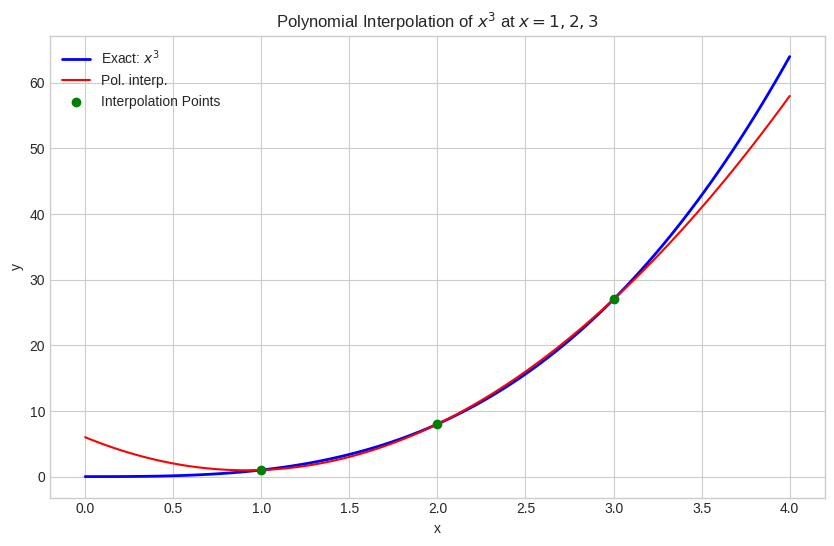

In [20]:
# Visualizar
x_plot = np.linspace(0, 4, 100)
y_exact = x_plot**3

y_lagrange = lagrange_interpolation(x_data, y_data, x_plot)

plt.plot(x_plot, y_exact, 'b-', label='Exact: $x^3$', linewidth=2)
plt.plot(x_plot, y_lagrange, 'r-', label='Pol. interp.', linewidth=1.5)
plt.scatter(x_data, y_data, color='green', zorder=5, label='Interpolation Points')

plt.title('Polynomial Interpolation of $x^3$ at $x = 1, 2, 3$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

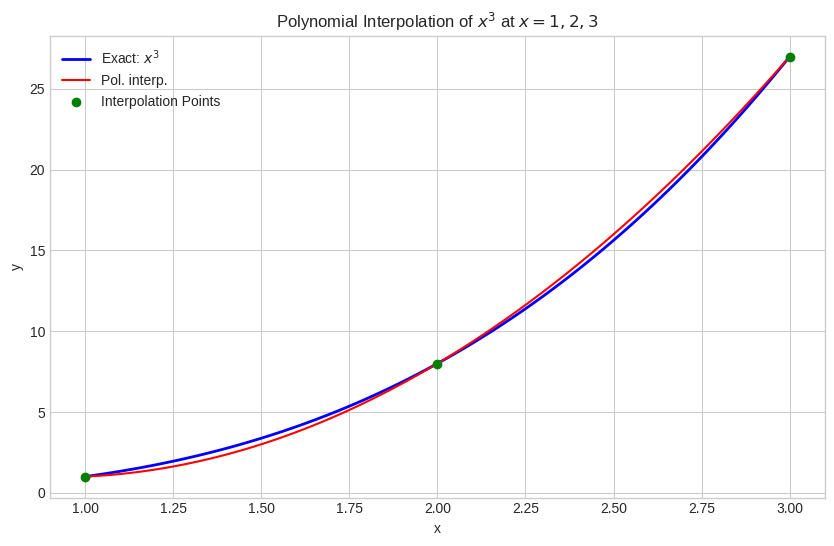

In [25]:
# Visualizar
x_plot = np.linspace(1, 3, 100)
y_exact = x_plot**3

y_lagrange = lagrange_interpolation(x_data, y_data, x_plot)

plt.plot(x_plot, y_exact, 'b-', label='Exact: $x^3$', linewidth=2)
plt.plot(x_plot, y_lagrange, 'r-', label='Pol. interp.', linewidth=1.5)
plt.scatter(x_data, y_data, color='green', zorder=5, label='Interpolation Points')

plt.title('Polynomial Interpolation of $x^3$ at $x = 1, 2, 3$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)

---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 1:</h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
# Espacio para tu codigo:


<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 2:</h3>
Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
# Espacio para tu codigo:



<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Ejercicio 3: </h3>
    Se anuncia durante el Laboratorio.
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [ ]:
# Espacio para tu codigo:


